In [6]:
import pandas as pd
from nrclex import NRCLex
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df_songs = pd.read_csv('dataset.csv')

In [3]:
def get_nrc_emotions(text):
    emotions = NRCLex()
    emotions.load_raw_text(text)
    return emotions.affect_frequencies

In [4]:
emotions = df_songs['lyrics_cleaned'].apply(lambda x: pd.Series(get_nrc_emotions(x)))

df_songs = pd.concat([df_songs,emotions],axis=1)

In [ ]:
# 1. Select only your emotion columns
features = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'joy', 'disgust', 'positive', 'negative']
X = df_songs[features]

# 2. Scale the data so every emotion has equal weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

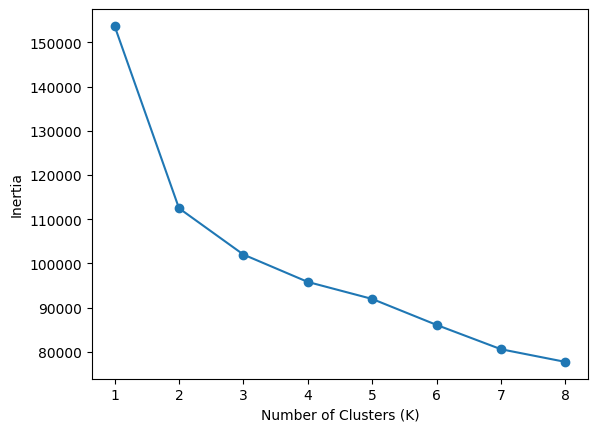

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
def plot_elbow(df: pd.DataFrame):
    '''
    Plots the elbow for clusters between 1 and 9

    Args:
        df (pd.DataFrame): dataframe being clustered
    '''
    inertia = []
    features = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'sadness', 'joy', 'disgust', 'positive', 'negative']
    X = df[features]

    # 2. Scale the data so every emotion has equal weight
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    k_range = range(1,9)

    for k in k_range:
        model = KMeans(n_clusters=k,random_state = 42)
        model.fit(X_scaled)
        inertia.append(model.inertia_)

    plt.plot(k_range, inertia, marker='o')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Inertia')
    plt.show()


plot_elbow(df_songs)